In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
from google.colab import files
import os

# 1. Upload the kaggle.json file
files.upload()

# 2. Set up the Kaggle directory
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# 3. Download the 2026 competition dataset
!kaggle competitions download -c march-machine-learning-mania-2026

# 4. Unzip the files
!unzip march-machine-learning-mania-2026.zip -d march_mania_data

Saving march-machine-learning-mania-2026.zip to march-machine-learning-mania-2026.zip
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication
Archive:  march-machine-learning-mania-2026.zip
  inflating: march_mania_data/Cities.csv  
  inflating: march_mania_data/Conferences.csv  
  inflating: march_mania_data/MConferenceTourneyGames.csv  
  inflating: march_mania_data/MGameCities.csv  
  inflating: march_mania_data/MMasseyOrdinals.csv  
  inflating: march_mania_data/MNCAATourneyCompactResults.csv  
  inflating: march_mania_data/MNCAATourneyDetailedResults.csv  
  inflating: march_mania_data/MNCAATourneySeedRoundSlots.csv  
  inflating: march_mania_data/MNCAATourneySeeds.csv  
  inflating: march_mania_data/MNCAATourneySlots.csv  
  inf

In [10]:
# Load the core files
DATA_PATH = 'march_mania_data/'
regular = pd.read_csv(f"{DATA_PATH}/MRegularSeasonCompactResults.csv")
tourney = pd.read_csv(f"{DATA_PATH}/MNCAATourneyCompactResults.csv")
seeds = pd.read_csv(f"{DATA_PATH}/MNCAATourneySeeds.csv")
teams = pd.read_csv(f"{DATA_PATH}/MTeams.csv")

In [11]:
regular.shape

(198577, 8)

In [12]:
tourney.shape

(2585, 8)

In [13]:
seeds.shape

(2694, 3)

In [14]:
teams.shape

(381, 4)

In [15]:
regular.head()

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT
0,1985,20,1228,81,1328,64,N,0
1,1985,25,1106,77,1354,70,H,0
2,1985,25,1112,63,1223,56,H,0
3,1985,25,1165,70,1432,54,H,0
4,1985,25,1192,86,1447,74,H,0


In [16]:
tourney.head()

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT
0,1985,136,1116,63,1234,54,N,0
1,1985,136,1120,59,1345,58,N,0
2,1985,136,1207,68,1250,43,N,0
3,1985,136,1229,58,1425,55,N,0
4,1985,136,1242,49,1325,38,N,0


In [17]:
seeds.head()

,Season,Seed,TeamID
0,1985,W01,1207
1,1985,W02,1210
2,1985,W03,1228
3,1985,W04,1260
4,1985,W05,1374


In [18]:
teams.head()

,TeamID,TeamName,FirstD1Season,LastD1Season
0,1101,Abilene Chr,2014,2026
1,1102,Air Force,1985,2026
2,1103,Akron,1985,2026
3,1104,Alabama,1985,2026
4,1105,Alabama A&M,2000,2026


# Seeds Cleaning

In [19]:
seeds['Seed'] = seeds['Seed'].str[1:3].astype(int)

In [20]:
seeds.tail()

,Season,Seed,TeamID
2689,2026,12,1219
2690,2026,13,1218
2691,2026,14,1244
2692,2026,15,1474
2693,2026,16,1254


# Create Team Statistics

In [21]:
# Step 1: Wins
wins = regular[['Season', 'WTeamID', 'WScore']].copy()
wins = wins.rename(columns={
    'WTeamID': 'TeamID',
    'WScore': 'Score'
})
wins['win'] = 1

# Step 2: Losses
losses = regular[['Season', 'LTeamID', 'LScore']].copy()
losses = losses.rename(columns={
    'LTeamID': 'TeamID',
    'LScore': 'Score'
})
losses['win'] = 0

# Step 3: Combine
all_games = pd.concat([wins, losses])

# Step 4: Group by team
team_stats = all_games.groupby(['Season', 'TeamID']).agg({
    'win': 'mean',
    'Score': 'mean'
}).reset_index()

team_stats = team_stats.rename(columns={
    'win': 'win_rate',
    'Score': 'avg_score'
})

team_stats.head()

,Season,TeamID,win_rate,avg_score
0,1985,1102,0.208333,63.083333
1,1985,1103,0.391304,61.043478
2,1985,1104,0.700000,68.500000
3,1985,1106,0.416667,71.625000
4,1985,1108,0.760000,83.000000


# Build Training Dataset

In [22]:
# Copy tournament data
df = tourney.copy()

# ---- Merge Team A (Winner) ----
df = df.merge(team_stats,
              left_on=['Season', 'WTeamID'],
              right_on=['Season', 'TeamID'])

df = df.rename(columns={
    'win_rate': 'A_win_rate',
    'avg_score': 'A_avg_score'
}).drop(columns=['TeamID'])

# ---- Merge Team B (Loser) ----
df = df.merge(team_stats,
              left_on=['Season', 'LTeamID'],
              right_on=['Season', 'TeamID'])

df = df.rename(columns={
    'win_rate': 'B_win_rate',
    'avg_score': 'B_avg_score'
}).drop(columns=['TeamID'])

# ---- Merge Seeds ----
df = df.merge(seeds,
              left_on=['Season', 'WTeamID'],
              right_on=['Season', 'TeamID'])

df = df.rename(columns={'Seed': 'A_seed'}).drop(columns=['TeamID'])

df = df.merge(seeds,
              left_on=['Season', 'LTeamID'],
              right_on=['Season', 'TeamID'])

df = df.rename(columns={'Seed': 'B_seed'}).drop(columns=['TeamID'])

# ---- Target ----
df['target'] = 1

In [23]:
df_rev = df.copy()

df_rev = df_rev.rename(columns={
    'A_win_rate': 'B_win_rate',
    'B_win_rate': 'A_win_rate',
    'A_avg_score': 'B_avg_score',
    'B_avg_score': 'A_avg_score',
    'A_seed': 'B_seed',
    'B_seed': 'A_seed'
})

df_rev['target'] = 0

final_df = pd.concat([df, df_rev], ignore_index=True)

In [24]:
final_df['score_ratio'] = final_df['A_avg_score'] / (final_df['B_avg_score'] + 1)
final_df['winrate_ratio'] = final_df['A_win_rate'] / (final_df['B_win_rate'] + 1e-5)
final_df['seed_ratio'] = final_df['A_seed'] / (final_df['B_seed'] + 1)

In [25]:
final_df.head()

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,A_win_rate,A_avg_score,B_win_rate,B_avg_score,A_seed,B_seed,target,score_ratio,winrate_ratio,seed_ratio
0,1985,136,1116,63,1234,54,N,0,0.636364,65.333333,0.666667,69.733333,9,8,1,0.923657,0.954531,1.000000
1,1985,136,1120,59,1345,58,N,0,0.620690,70.344828,0.680000,69.120000,11,6,1,1.003206,0.912765,1.571429
2,1985,136,1207,68,1250,43,N,0,0.925926,75.740741,0.379310,65.758621,1,16,1,1.134546,2.441013,0.058824
3,1985,136,1229,58,1425,55,N,0,0.740741,71.592593,0.678571,68.392857,9,8,1,1.031700,1.091602,1.000000
4,1985,136,1242,49,1325,38,N,0,0.766667,76.033333,0.740741,67.555556,3,14,1,1.109076,1.034986,0.200000


# Prepare Data

In [54]:
final_df['seed_diff'] = final_df['A_seed'] - final_df['B_seed']
final_df['winrate_diff'] = final_df['A_win_rate'] - final_df['B_win_rate']
final_df['score_diff'] = final_df['A_avg_score'] - final_df['B_avg_score']

features = ['seed_diff',
    'seed_ratio',
    'score_diff',
    'winrate_diff']

X = final_df[features]
y = final_df['target']

# Train-Test Split

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model 1 — Logistic Regression

In [56]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)

LogisticRegression()

In [57]:
print("LR Train Score:", lr.score(X_train, y_train))
print("LR Test Score:", lr.score(X_val, y_val))

LR Train Score: 0.6997098646034816
LR Test Score: 0.7350096711798839


# Model 2 — XGBoost

In [58]:
import xgboost as xgb

model = xgb.XGBClassifier(
    n_estimators=50,
    max_depth=2,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1,
    reg_lambda=1,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

print("XGB Train Score:", model.score(X_train, y_train))
print("XGB Val Score:", model.score(X_val, y_val))

XGB Train Score: 0.7026112185686654
XGB Val Score: 0.730174081237911


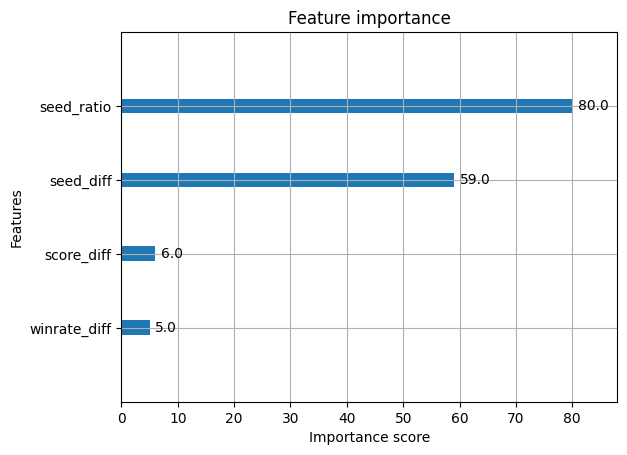

In [59]:
import matplotlib.pyplot as plt

xgb.plot_importance(model)
plt.show()

# Load Sample Submission

In [81]:
sample_submission = pd.read_csv(f"{DATA_PATH}/SampleSubmissionStage2.csv")
print(sample_submission.shape)
sample_submission.head()

(132133, 2)


,ID,Pred
0,2026_1101_1102,0.5
1,2026_1101_1103,0.5
2,2026_1101_1104,0.5
3,2026_1101_1105,0.5
4,2026_1101_1106,0.5


# Split ID into Teams

In [82]:
def extract(row):
    season, t1, t2 = row.split('_')
    return int(season), int(t1), int(t2)

sample_submission[['Season', 'Team1', 'Team2']] = sample_submission['ID'].apply(
    lambda x: pd.Series(extract(x))
)

In [83]:
sub_df = sample_submission.copy()

# Merge Team Stats

In [84]:
# Team A
sub_df = sub_df.merge(team_stats,
                      left_on=['Season', 'Team1'],
                      right_on=['Season', 'TeamID'],
                      how='left')

sub_df = sub_df.rename(columns={
    'win_rate': 'A_win_rate',
    'avg_score': 'A_avg_score'
}).drop(columns=['TeamID'])

# Team B
sub_df = sub_df.merge(team_stats,
                      left_on=['Season', 'Team2'],
                      right_on=['Season', 'TeamID'],
                      how='left')

sub_df = sub_df.rename(columns={
    'win_rate': 'B_win_rate',
    'avg_score': 'B_avg_score'
}).drop(columns=['TeamID'])

# Merge Seeds

In [85]:
# Team A seed
sub_df = sub_df.merge(seeds,
                      left_on=['Season', 'Team1'],
                      right_on=['Season', 'TeamID'],
                      how='left')

sub_df = sub_df.rename(columns={'Seed': 'A_seed'}).drop(columns=['TeamID'])

# Team B seed
sub_df = sub_df.merge(seeds,
                      left_on=['Season', 'Team2'],
                      right_on=['Season', 'TeamID'],
                      how='left')

sub_df = sub_df.rename(columns={'Seed': 'B_seed'}).drop(columns=['TeamID'])

# Fill Missing Values

In [86]:
sub_df = sub_df.fillna(0)

# Create Features

In [87]:
sub_df['seed_diff'] = sub_df['A_seed'] - sub_df['B_seed']
sub_df['seed_ratio'] = sub_df['A_seed'] / (sub_df['B_seed'] + 1)

sub_df['winrate_diff'] = sub_df['A_win_rate'] - sub_df['B_win_rate']
sub_df['score_diff'] = sub_df['A_avg_score'] - sub_df['B_avg_score']

# Predict

In [90]:
features = ['seed_diff', 'seed_ratio', 'score_diff', 'winrate_diff']

sub_df['Pred'] = model.predict_proba(sub_df[features])[:, 1]

# Final Submission File

In [91]:
final_submission = sub_df[['ID', 'Pred']]
final_submission.to_csv("submission.csv", index=False)

print(final_submission.shape)
final_submission.head()

(132133, 2)


,ID,Pred
0,2026_1101_1102,0.736102
1,2026_1101_1103,0.884585
2,2026_1101_1104,0.765229
3,2026_1101_1105,0.722776
4,2026_1101_1106,0.722776


# Download (Colab)

In [92]:
from google.colab import files
files.download("submission.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>